# Titanic Survival Prediction
### End-to-end Machine Learning Pipeline

The Titanic dataset is one of the most well-known datasets in data science - but the goal here is not to simply achieve a high accuracy score. 
The goal is to build a **thoughtful, well-documented ML pipeline** that 
demonstrates analytical thinking, deliberate feature engineering, and 
interpretable modelling decisions.

**Dataset:** Kaggle Titanic - 891 passengers, 12 features  
**Target:** Survived (0 = Did not survive, 1 = Survived)  
**Approach:** EDA -> Feature Engineering -> Preprocessing -> Modelling -> Explainability


## Environment Setup

Importing core libraries for data manipulation, numerical computation, 
and visualisation. All plots are saved as PNG files for reproducibility 
and portfolio documentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mlt

## Data Loading

Loading the raw Titanic dataset. Before any analysis, the first step is 
always to load and verify the data is intact - correct shape, expected 
columns, and no silent load errors.

In [2]:
data = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### First Look

Inspecting the first and last few rows to get an immediate sense of 
the data structure - what features exist, what the values look like, 
and whether anything looks immediately unusual.

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Shape and Column Inventory

Verifying dimensions and column names before any transformation. 
This is a simple but critical checkpoint - confirming we have the 
expected 891 rows and 12 columns before proceeding.

In [7]:
df.shape

(891, 12)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Data Types and Memory

Understanding data types matters because it determines which 
preprocessing steps are needed - numeric features need scaling, 
categorical features need encoding. Mixed types or unexpected 
object columns here signal cleaning work ahead.

In [11]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Statistical Summary

Descriptive statistics for all numeric features. Key things to look 
for here:
- **Min/max outliers** - Fare has a known extreme right tail
- **Mean vs median gaps** - signals skewness
- **Count vs total rows** - any count below 891 indicates missing values

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Boxplot Overview

A quick visual scan of all numeric distributions simultaneously. 
Boxplots are particularly useful at this stage for spotting outliers 
before making imputation or scaling decisions.

<AxesSubplot:>

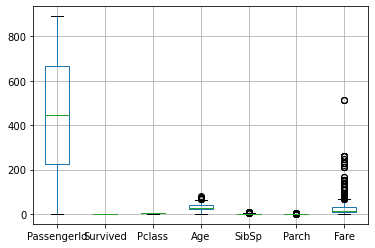

In [14]:
df.boxplot(fontsize='medium',)

### Missing Value Analysis

Identifying missing data before any transformation is non-negotiable.
Imputation decisions - whether to use mean, median, mode, or model-based
imputation - depend on both the percentage missing and the feature's
relationship with the target variable.

          Missing Count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


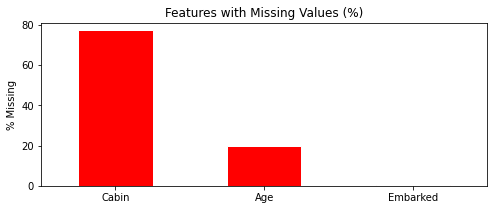

In [30]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)

# Visual
fig, ax = plt.subplots(figsize=(8, 3))
missing_df['Missing %'].plot(kind='bar', color='red',edgecolor='white', ax=ax)
ax.set_title('Features with Missing Values (%)')
ax.set_ylabel('% Missing')
plt.xticks(rotation=0)
plt.savefig('eda_04_missing_values.png', dpi=100)

## Target Variable Analysis

Before any feature analysis, understanding the target variable is 
the most important step. Class imbalance in the target directly affects 
model evaluation strategy - a heavily imbalanced target can produce 
a model that appears accurate but simply predicts the majority class.

In [15]:
df["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [16]:
df["Survived"].value_counts(normalize=True)

0    0.616162
1    0.383838
Name: Survived, dtype: float64

In [28]:
survival_counts = df["Survived"].value_counts()
survival_pct = df["Survived"].value_counts(normalize=True) * 100

print(f"Did not survive : {survival_counts[0]} ({survival_pct[0]:.1f}%)")
print(f"Survived        : {survival_counts[1]} ({survival_pct[1]:.1f}%)")
print(f"Total passengers: {survival_counts.sum()}")

Did not survive : 549 (61.6%)
Survived        : 342 (38.4%)
Total passengers: 891


### Survival Distribution

**Finding:** 61.6% of passengers did not survive (549), 38.4% survived (342).  
This is a **moderate imbalance** - worth monitoring during model evaluation 
but not severe enough to require resampling techniques like SMOTE at this stage. 
Evaluation will prioritise F1-score and ROC-AUC over raw accuracy.

In [20]:
import matplotlib.pyplot as plt

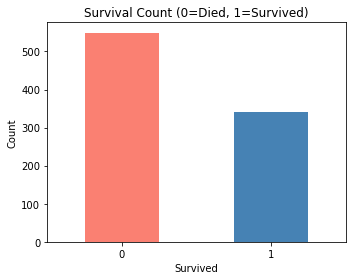

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Survived"].value_counts().plot(kind="bar", color=["salmon", "steelblue"], ax=ax)
ax.set_title("Survival Count (0=Died, 1=Survived)")
ax.set_xlabel("Survived")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_01_survived_count.png", dpi=100)

In [23]:
plt.close()

## Univariate Feature Analysis

Analysing each feature independently before looking at relationships 
with the target. The goal here is to understand distributions, spot 
skewness, and identify missing values - all of which inform preprocessing 
decisions later.

### Numeric Features - Age and Fare

Two continuous features with very different characteristics:
- **Age** - roughly normal distribution but with 177 missing values (19.9% of data). 
  Imputation strategy will be decided after examining survival patterns by age group.
- **Fare** - heavily right-skewed with extreme outliers. 
  Log transformation will likely be needed before modelling.

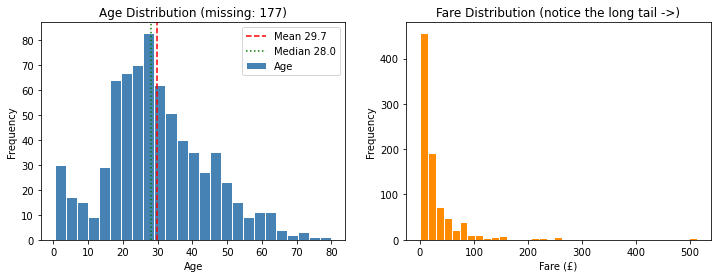

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Age — continuous, has missing values
df["Age"].plot(kind="hist", bins=25, color="steelblue",edgecolor="white", ax=axes[0])
axes[0].axvline(df["Age"].mean(),   color="red",   linestyle="--", label=f"Mean {df['Age'].mean():.1f}")
axes[0].axvline(df["Age"].median(), color="green", linestyle=":",  label=f"Median {df['Age'].median():.1f}")
axes[0].legend()
axes[0].set_title(f"Age Distribution (missing: {df['Age'].isnull().sum()})")
axes[0].set_xlabel("Age")
 
# Fare — continuous, right-skewed
df["Fare"].plot(kind="hist", bins=35, color="darkorange",edgecolor="white", ax=axes[1])
axes[1].set_title("Fare Distribution (notice the long tail ->)")
axes[1].set_xlabel("Fare (£)")
plt.savefig("eda_02_numeric_histograms.png", dpi=100)

### Categorical Features - Sex, Pclass, Embarked

Three categorical features that are expected to have strong relationships 
with survival based on domain knowledge of the disaster:
- **Sex** - "women and children first" protocol was reportedly followed
- **Pclass** - ticket class as a proxy for socioeconomic status
- **Embarked** - port of embarkation (Southampton, Cherbourg, Queenstown)

Distribution counts here establish the baseline before cross-tabulating 
with survival in the next section.

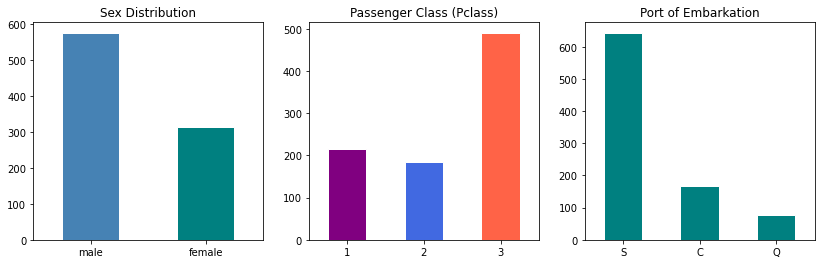

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
# Sex
df["Sex"].value_counts().plot(kind="bar", color=["steelblue", "teal"],ax=axes[0], edgecolor="white")
axes[0].set_title("Sex Distribution")
axes[0].tick_params(axis="x", rotation=0)
 
# Pclass — ordinal (order matters: 1 > 2 > 3)
df["Pclass"].value_counts().sort_index().plot(kind="bar",color=["purple", "royalblue", "tomato"], ax=axes[1], edgecolor="white")
axes[1].set_title("Passenger Class (Pclass)")
axes[1].tick_params(axis="x", rotation=0)
 
# Embarked — nominal (no order)
df["Embarked"].value_counts().plot(kind="bar", color="teal",ax=axes[2], edgecolor="white")
axes[2].set_title("Port of Embarkation")
axes[2].tick_params(axis="x", rotation=0)
plt.savefig("eda_03_categorical_bars.png", dpi=100)

In [27]:
plt.close()

## Next Steps

Univariate analysis complete. The following patterns warrant further investigation:

- **Missing values:** Age (177), Cabin (687), Embarked (2) - imputation strategy TBD
- **Fare skewness:** Log transformation likely needed
- **Feature relationships:** Survival rate by Sex, Pclass, Age group - next section
- **Feature engineering candidates:** Title from Name, Family size from SibSp + Parch, 
  Deck from Cabin

*Work in progress.*